# NYC Yellow Cab - Data Preprocessing and EDA
## January 2024 Dataset Analysis

This notebook implements comprehensive data preprocessing and exploratory data analysis.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

print('Libraries imported successfully!')

Libraries imported successfully!


In [2]:
df_raw = pd.read_parquet('yellow_tripdata_2024-01.parquet')
print(f'Dataset shape: {df_raw.shape}')
print(f'Number of trips: {len(df_raw):,}')
print(f'Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB')
df_raw.head()

Dataset shape: (2964624, 19)
Number of trips: 2,964,624
Memory usage: 511.09 MB


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-01-01 00:57:55,2024-01-01 01:17:43,1.0,1.72,1.0,N,186,79,2,17.7,1.0,0.5,0.00,0.0,1.0,22.70,2.5,0.0
1,1,2024-01-01 00:03:00,2024-01-01 00:09:36,1.0,1.80,1.0,N,140,236,1,10.0,3.5,0.5,3.75,0.0,1.0,18.75,2.5,0.0
2,1,2024-01-01 00:17:06,2024-01-01 00:35:01,1.0,4.70,1.0,N,236,79,1,23.3,3.5,0.5,3.00,0.0,1.0,31.30,2.5,0.0
3,1,2024-01-01 00:36:38,2024-01-01 00:44:56,1.0,1.40,1.0,N,79,211,1,10.0,3.5,0.5,2.00,0.0,1.0,17.00,2.5,0.0
4,1,2024-01-01 00:46:51,2024-01-01 00:52:57,1.0,0.80,1.0,N,211,148,1,7.9,3.5,0.5,3.20,0.0,1.0,16.10,2.5,0.0


## 2. Data Quality Assessment

In [3]:
print('MISSING VALUES ANALYSIS')
print('='*70)
missing = pd.DataFrame({
    'Count': df_raw.isnull().sum(),
    'Percentage': (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
})
print(missing[missing['Count'] > 0])
print(f'\nDuplicates: {df_raw.duplicated().sum():,}')

MISSING VALUES ANALYSIS
                       Count  Percentage
passenger_count       140162        4.73
RatecodeID            140162        4.73
store_and_fwd_flag    140162        4.73
congestion_surcharge  140162        4.73
Airport_fee           140162        4.73

Duplicates: 0


In [4]:
print('STATISTICAL SUMMARY')
print('='*70)
df_raw.describe()

STATISTICAL SUMMARY


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
count,2.964624e+06,2964624,2964624,2.824462e+06,2.964624e+06,2.824462e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.964624e+06,2.824462e+06,2.824462e+06
mean,1.754204e+00,2024-01-17 00:46:36.431092,2024-01-17 01:02:13.208130,1.339281e+00,3.652169e+00,2.069359e+00,1.660179e+02,1.651167e+02,1.161271e+00,1.817506e+01,1.451598e+00,4.833823e-01,3.335870e+00,5.270212e-01,9.756319e-01,2.680150e+01,2.256122e+00,1.411611e-01
min,1.000000e+00,2002-12-31 22:59:39,2002-12-31 23:05:41,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,-8.990000e+02,-7.500000e+00,-5.000000e-01,-8.000000e+01,-8.000000e+01,-1.000000e+00,-9.000000e+02,-2.500000e+00,-1.750000e+00
25%,2.000000e+00,2024-01-09 15:59:19.750000,2024-01-09 16:16:23,1.000000e+00,1.000000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,8.600000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.538000e+01,2.500000e+00,0.000000e+00
50%,2.000000e+00,2024-01-17 10:45:37.500000,2024-01-17 11:03:51.500000,1.000000e+00,1.680000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.280000e+01,1.000000e+00,5.000000e-01,2.700000e+00,0.000000e+00,1.000000e+00,2.010000e+01,2.500000e+00,0.000000e+00
75%,2.000000e+00,2024-01-24 18:23:52.250000,2024-01-24 18:40:29,1.000000e+00,3.110000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.050000e+01,2.500000e+00,5.000000e-01,4.120000e+00,0.000000e+00,1.000000e+00,2.856000e+01,2.500000e+00,0.000000e+00
max,6.000000e+00,2024-02-01 00:01:15,2024-02-02 13:56:52,9.000000e+00,3.127223e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,5.000000e+03,1.425000e+01,4.000000e+00,4.280000e+02,1.159200e+02,1.000000e+00,5.000000e+03,2.500000e+00,1.750000e+00
std,4.325902e-01,NaN,NaN,8.502817e-01,2.254626e+02,9.823219e+00,6.362391e+01,6.931535e+01,5.808686e-01,1.894955e+01,1.804102e+00,1.177600e-01,3.896551e+00,2.128310e+00,2.183645e-01,2.338558e+01,8.232747e-01,4.876239e-01


## 3. Anomaly Detection

In [5]:
df_raw['trip_duration_minutes'] = (df_raw['tpep_dropoff_datetime'] - df_raw['tpep_pickup_datetime']).dt.total_seconds() / 60

print('TEMPORAL ANOMALIES')
print('='*70)
print(f'Pickup range: {df_raw["tpep_pickup_datetime"].min()} to {df_raw["tpep_pickup_datetime"].max()}')
print(f'Negative durations: {(df_raw["trip_duration_minutes"] < 0).sum():,}')
print(f'Durations > 3 hours: {(df_raw["trip_duration_minutes"] > 180).sum():,}')

jan_2024 = df_raw[(df_raw['tpep_pickup_datetime'] >= '2024-01-01') & (df_raw['tpep_pickup_datetime'] < '2024-02-01')]
print(f'\nTrips in January 2024: {len(jan_2024):,} ({len(jan_2024)/len(df_raw)*100:.2f}%)')

TEMPORAL ANOMALIES
Pickup range: 2002-12-31 22:59:39 to 2024-02-01 00:01:15
Negative durations: 56
Durations > 3 hours: 1,983

Trips in January 2024: 2,964,606 (100.00%)


In [6]:
print('FINANCIAL ANOMALIES')
print('='*70)
print(f'Negative fares: {(df_raw["fare_amount"] < 0).sum():,}')
print(f'Zero fares: {(df_raw["fare_amount"] == 0).sum():,}')
print(f'Fares > $100: {(df_raw["fare_amount"] > 100).sum():,}')
print(f'Fare range: ${df_raw["fare_amount"].min():.2f} to ${df_raw["fare_amount"].max():.2f}')

print(f'\nZero distance: {(df_raw["trip_distance"] == 0).sum():,}')
print(f'Distance > 50 miles: {(df_raw["trip_distance"] > 50).sum():,}')

FINANCIAL ANOMALIES
Negative fares: 37,448
Zero fares: 893
Fares > $100: 7,995
Fare range: $-899.00 to $5000.00

Zero distance: 60,371
Distance > 50 miles: 412


## 4. Data Cleaning and Preprocessing

In [7]:
df = df_raw.copy()
print(f'Starting with {len(df):,} records')
print('='*70)

# Filter to January 2024
df = df[(df['tpep_pickup_datetime'] >= '2024-01-01') & (df['tpep_pickup_datetime'] < '2024-02-01')]
print(f'After date filter: {len(df):,}')

# Remove invalid durations
df = df[(df['trip_duration_minutes'] > 0) & (df['trip_duration_minutes'] <= 180)]
print(f'After duration filter: {len(df):,}')

# Remove invalid fares
df = df[(df['fare_amount'] >= 0) & (df['fare_amount'] <= 500)]
df = df[(df['total_amount'] >= 0) & (df['tip_amount'] >= 0)]
print(f'After fare filter: {len(df):,}')

# Remove invalid distances
df = df[(df['trip_distance'] > 0) & (df['trip_distance'] <= 100)]
print(f'After distance filter: {len(df):,}')

# Handle passenger count
df['passenger_count'].fillna(df['passenger_count'].median(), inplace=True)
df = df[(df['passenger_count'] > 0) & (df['passenger_count'] <= 6)]
print(f'After passenger filter: {len(df):,}')

# Fill remaining missing values
df['RatecodeID'].fillna(df['RatecodeID'].mode()[0], inplace=True)
df['store_and_fwd_flag'].fillna('N', inplace=True)
df['congestion_surcharge'].fillna(0, inplace=True)
df['Airport_fee'].fillna(0, inplace=True)

print(f'\nFinal: {len(df):,} records ({len(df)/len(df_raw)*100:.1f}% retained)')
print(f'Removed: {len(df_raw)-len(df):,} records')

Starting with 2,964,624 records
After date filter: 2,964,606
After duration filter: 2,961,753
After fare filter: 2,924,162
After distance filter: 2,867,966
After passenger filter: 2,837,246

Final: 2,837,246 records (95.7% retained)
Removed: 127,378 records


## 5. Feature Engineering

In [8]:
print('CREATING DERIVED FEATURES')
print('='*70)

# Temporal features
df['pickup_date'] = df['tpep_pickup_datetime'].dt.date
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['pickup_day_num'] = df['tpep_pickup_datetime'].dt.dayofweek
df['is_weekend'] = df['pickup_day_num'].isin([5, 6]).astype(int)
df['is_peak_hour'] = df['pickup_hour'].isin([18, 19, 20]).astype(int)

# Financial features
df['fare_per_mile'] = df['fare_amount'] / df['trip_distance']
df['fare_per_minute'] = df['fare_amount'] / df['trip_duration_minutes']
df['tip_percentage'] = np.where(df['fare_amount'] > 0, (df['tip_amount'] / df['fare_amount']) * 100, 0)
df['has_tip'] = (df['tip_amount'] > 0).astype(int)

# Trip features
df['speed_mph'] = df['trip_distance'] / (df['trip_duration_minutes'] / 60)

print(f'Total features: {df.shape[1]}')
print('Features created successfully!')

CREATING DERIVED FEATURES
Total features: 31
Features created successfully!


## 6. Exploratory Data Analysis
### 6.1 Temporal Patterns

TEMPORAL PATTERNS
Avg trips/day: 91524
Busiest: 2024-01-27 (105,933 trips)
Quietest: 2024-01-07 (64,522 trips)


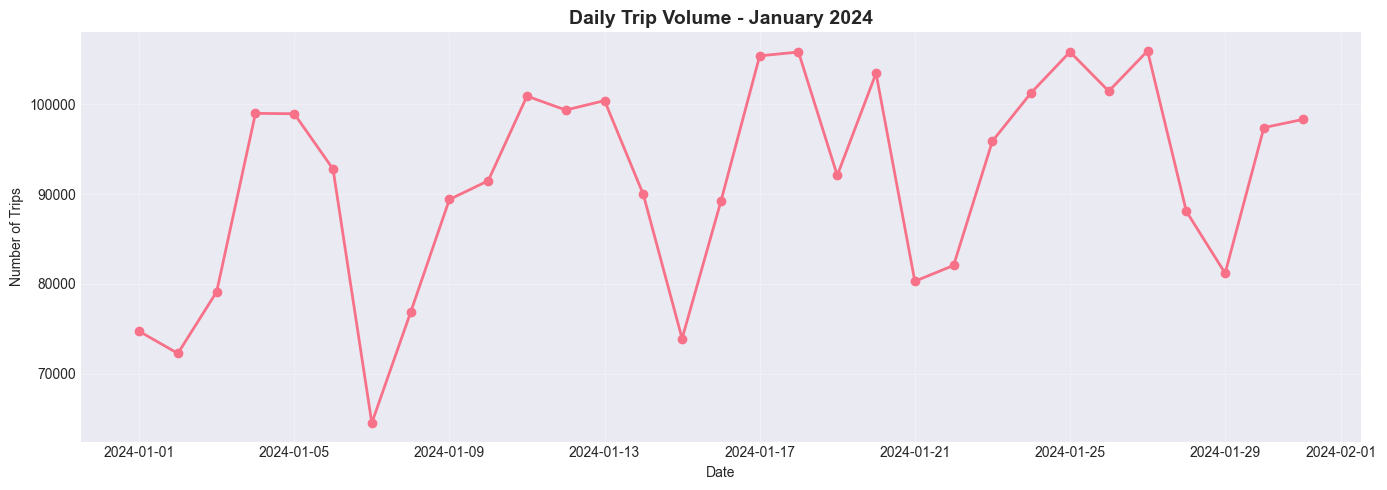

In [9]:
print('TEMPORAL PATTERNS')
print('='*70)

daily_trips = df.groupby('pickup_date').size()
print(f'Avg trips/day: {daily_trips.mean():.0f}')
print(f'Busiest: {daily_trips.idxmax()} ({daily_trips.max():,} trips)')
print(f'Quietest: {daily_trips.idxmin()} ({daily_trips.min():,} trips)')

plt.figure(figsize=(14, 5))
daily_trips.plot(kind='line', marker='o', linewidth=2)
plt.title('Daily Trip Volume - January 2024', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Number of Trips')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

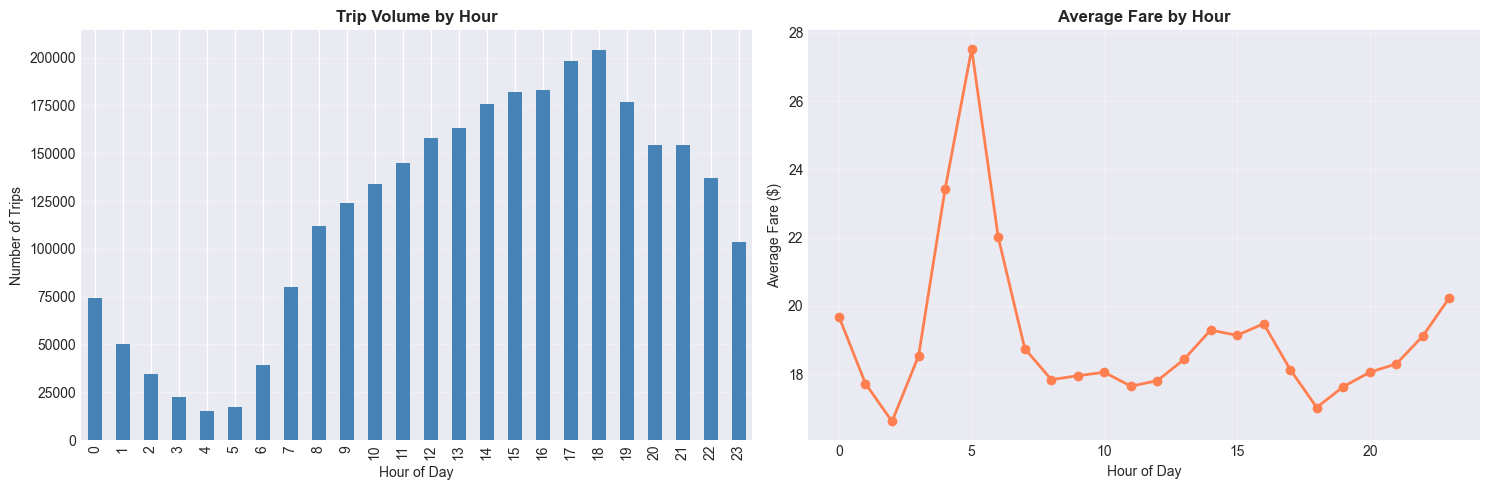

Busiest hour: 18:00 (204,052 trips)
Highest avg fare hour: 5:00 ($27.52)


In [10]:
hourly_trips = df.groupby('pickup_hour').size()
hourly_fare = df.groupby('pickup_hour')['fare_amount'].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

hourly_trips.plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Trip Volume by Hour', fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True, alpha=0.3, axis='y')

hourly_fare.plot(kind='line', ax=axes[1], marker='o', linewidth=2, color='coral')
axes[1].set_title('Average Fare by Hour', fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Average Fare ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Busiest hour: {hourly_trips.idxmax()}:00 ({hourly_trips.max():,} trips)')
print(f'Highest avg fare hour: {hourly_fare.idxmax()}:00 (${hourly_fare.max():.2f})')

### 6.2 Financial Analysis

FARE ANALYSIS
count    2.837246e+06
mean     1.850258e+01
std      1.706325e+01
min      0.000000e+00
25%      8.600000e+00
50%      1.280000e+01
75%      2.050000e+01
max      5.000000e+02
Name: fare_amount, dtype: float64


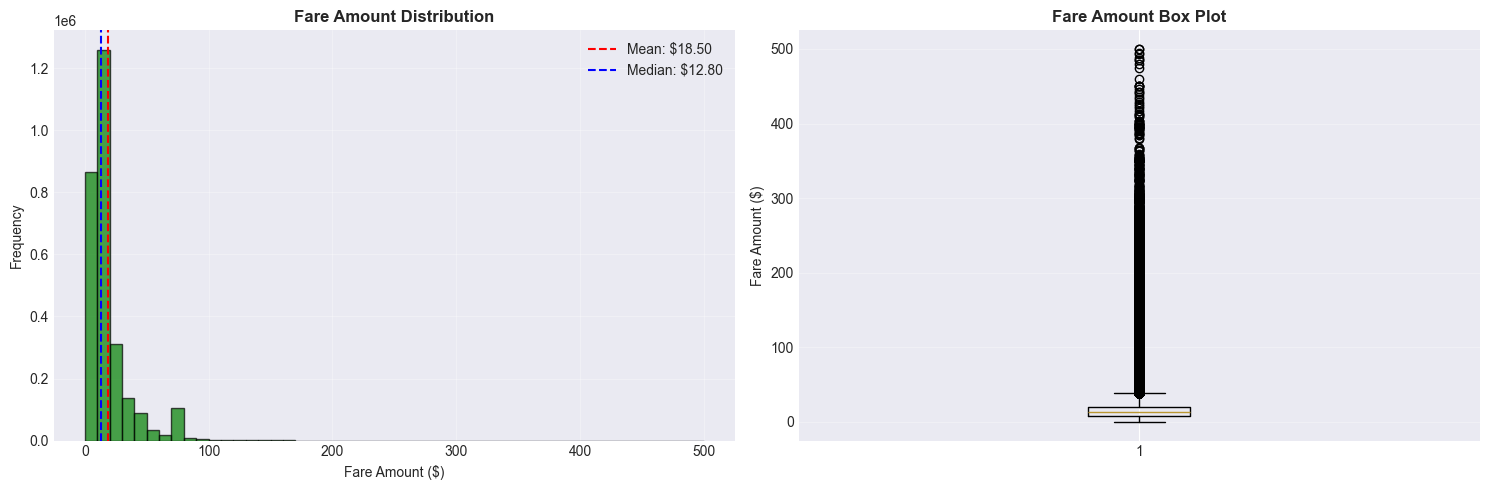

In [11]:
print('FARE ANALYSIS')
print('='*70)
print(df['fare_amount'].describe())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df['fare_amount'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[0].axvline(df['fare_amount'].mean(), color='red', linestyle='--', label=f'Mean: ${df["fare_amount"].mean():.2f}')
axes[0].axvline(df['fare_amount'].median(), color='blue', linestyle='--', label=f'Median: ${df["fare_amount"].median():.2f}')
axes[0].set_title('Fare Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Fare Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(df['fare_amount'], vert=True)
axes[1].set_title('Fare Amount Box Plot', fontweight='bold')
axes[1].set_ylabel('Fare Amount ($)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

TIP ANALYSIS
Trips with tips: 2,213,882 (78.0%)
Avg tip: $4.36
Avg tip %: 26.8%


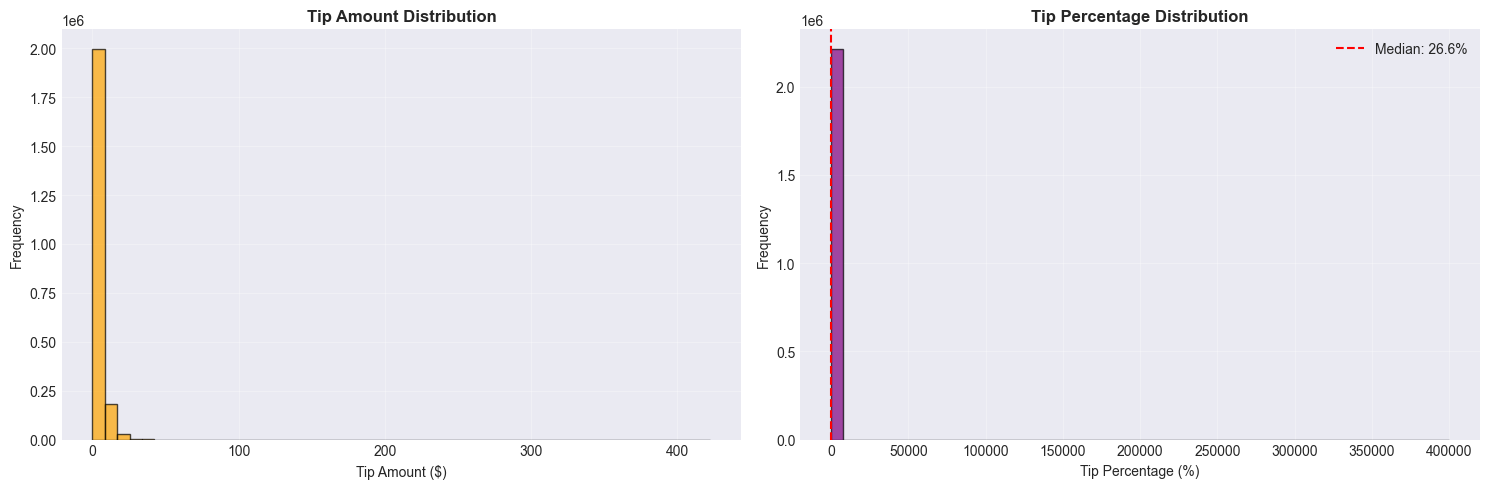

In [12]:
print('TIP ANALYSIS')
print('='*70)

tips_df = df[df['tip_amount'] > 0]
print(f'Trips with tips: {len(tips_df):,} ({len(tips_df)/len(df)*100:.1f}%)')
print(f'Avg tip: ${tips_df["tip_amount"].mean():.2f}')
print(f'Avg tip %: {tips_df["tip_percentage"].mean():.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(tips_df['tip_amount'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[0].set_title('Tip Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Tip Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(tips_df['tip_percentage'], bins=50, edgecolor='black', alpha=0.7, color='purple')
axes[1].axvline(tips_df['tip_percentage'].median(), color='red', linestyle='--', 
               label=f'Median: {tips_df["tip_percentage"].median():.1f}%')
axes[1].set_title('Tip Percentage Distribution', fontweight='bold')
axes[1].set_xlabel('Tip Percentage (%)')
axes[1].set_ylabel('Frequency')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.3 Trip Characteristics

TRIP CHARACTERISTICS
Distance stats:
count    2.837246e+06
mean     3.296857e+00
std      4.375176e+00
min      1.000000e-02
25%      1.020000e+00
50%      1.700000e+00
75%      3.190000e+00
max      9.750000e+01
Name: trip_distance, dtype: float64

Duration stats (minutes):
count    2.837246e+06
mean     1.496835e+01
std      1.181789e+01
min      1.666667e-02
25%      7.283333e+00
50%      1.173333e+01
75%      1.875000e+01
max      1.790667e+02
Name: trip_duration_minutes, dtype: float64


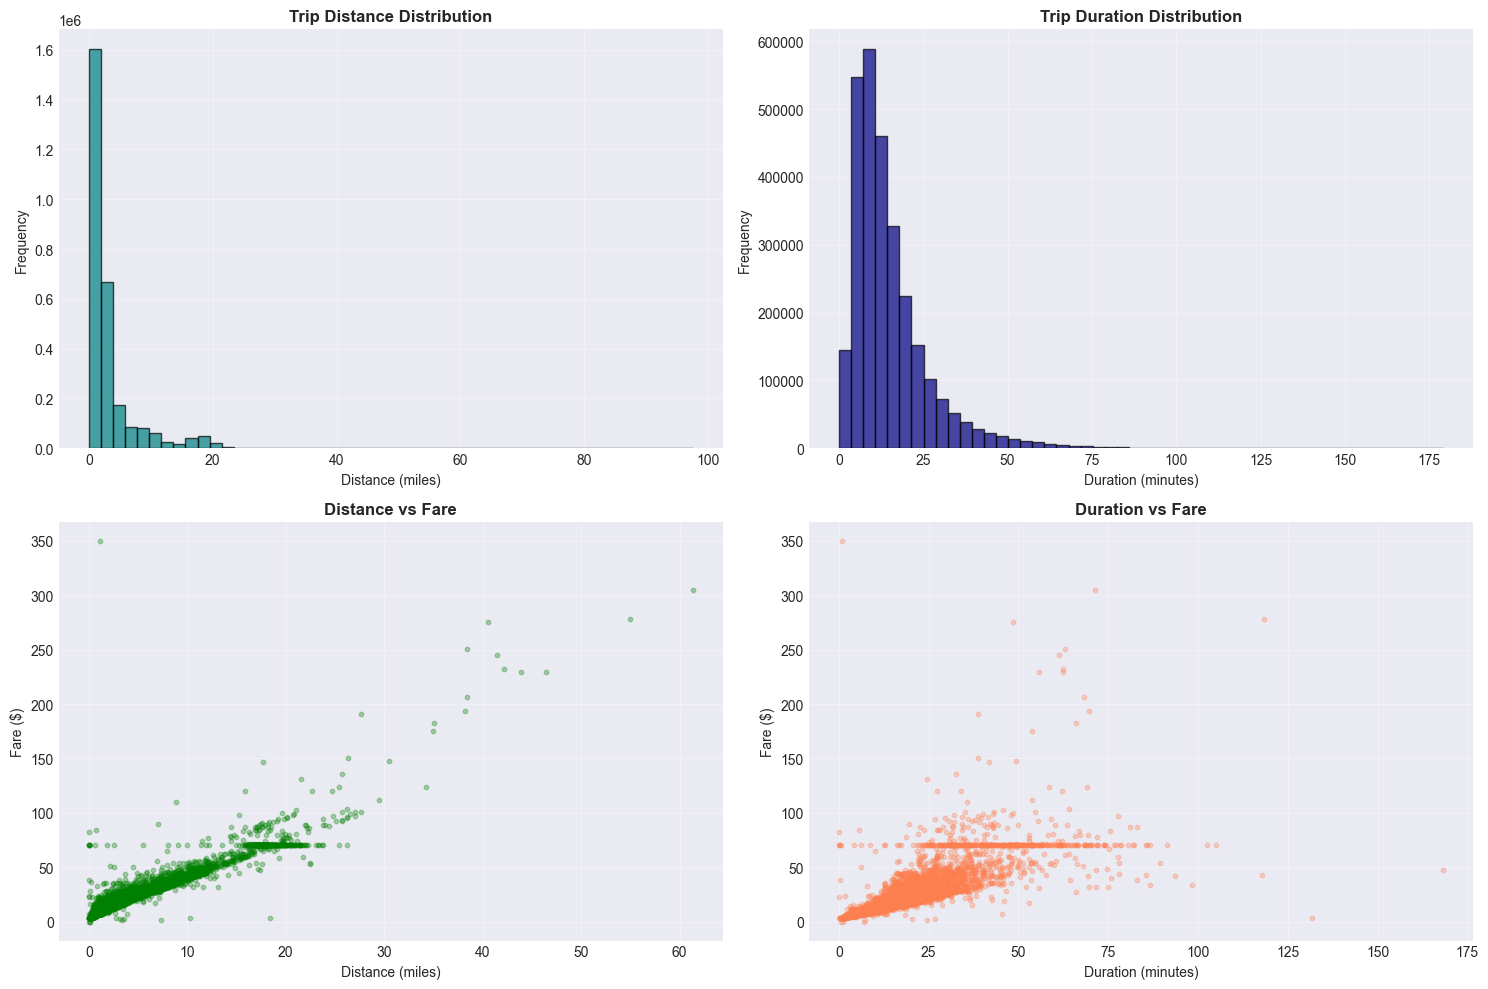

In [13]:
print('TRIP CHARACTERISTICS')
print('='*70)
print('Distance stats:')
print(df['trip_distance'].describe())
print('\nDuration stats (minutes):')
print(df['trip_duration_minutes'].describe())

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distance distribution
axes[0, 0].hist(df['trip_distance'], bins=50, edgecolor='black', alpha=0.7, color='teal')
axes[0, 0].set_title('Trip Distance Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Distance (miles)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(True, alpha=0.3)

# Duration distribution
axes[0, 1].hist(df['trip_duration_minutes'], bins=50, edgecolor='black', alpha=0.7, color='navy')
axes[0, 1].set_title('Trip Duration Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Duration (minutes)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(True, alpha=0.3)

# Distance vs Fare
sample = df.sample(n=min(10000, len(df)), random_state=42)
axes[1, 0].scatter(sample['trip_distance'], sample['fare_amount'], alpha=0.3, s=10, color='green')
axes[1, 0].set_title('Distance vs Fare', fontweight='bold')
axes[1, 0].set_xlabel('Distance (miles)')
axes[1, 0].set_ylabel('Fare ($)')
axes[1, 0].grid(True, alpha=0.3)

# Duration vs Fare
axes[1, 1].scatter(sample['trip_duration_minutes'], sample['fare_amount'], alpha=0.3, s=10, color='coral')
axes[1, 1].set_title('Duration vs Fare', fontweight='bold')
axes[1, 1].set_xlabel('Duration (minutes)')
axes[1, 1].set_ylabel('Fare ($)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 6.4 Categorical Analysis

PAYMENT METHOD ANALYSIS
payment_method
Credit Card    2272120
Cash            417326
Unknown         115216
Dispute          22709
No Charge         9875
Name: count, dtype: int64


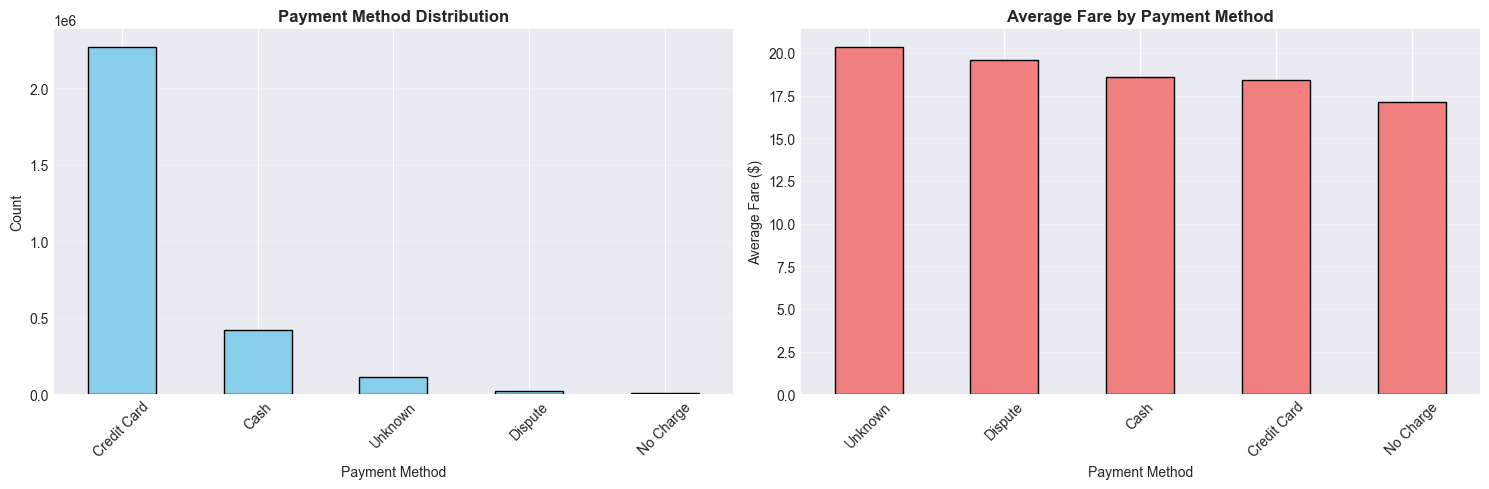

In [14]:
payment_map = {1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 0: 'Unknown'}
df['payment_method'] = df['payment_type'].map(payment_map)

print('PAYMENT METHOD ANALYSIS')
print('='*70)
payment_dist = df['payment_method'].value_counts()
print(payment_dist)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

payment_dist.plot(kind='bar', ax=axes[0], color='skyblue', edgecolor='black')
axes[0].set_title('Payment Method Distribution', fontweight='bold')
axes[0].set_xlabel('Payment Method')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3, axis='y')

payment_fare = df.groupby('payment_method')['fare_amount'].mean().sort_values(ascending=False)
payment_fare.plot(kind='bar', ax=axes[1], color='lightcoral', edgecolor='black')
axes[1].set_title('Average Fare by Payment Method', fontweight='bold')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Average Fare ($)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

VENDOR ANALYSIS
VendorID
2    2171910
1     665128
6        208
Name: count, dtype: int64

Vendor Statistics:
          fare_amount  tip_amount  trip_distance  trip_duration_minutes
VendorID                                                               
1               17.50        3.12           3.13                  15.69
2               18.81        3.49           3.35                  14.74
6               50.23        0.00          12.24                  50.80


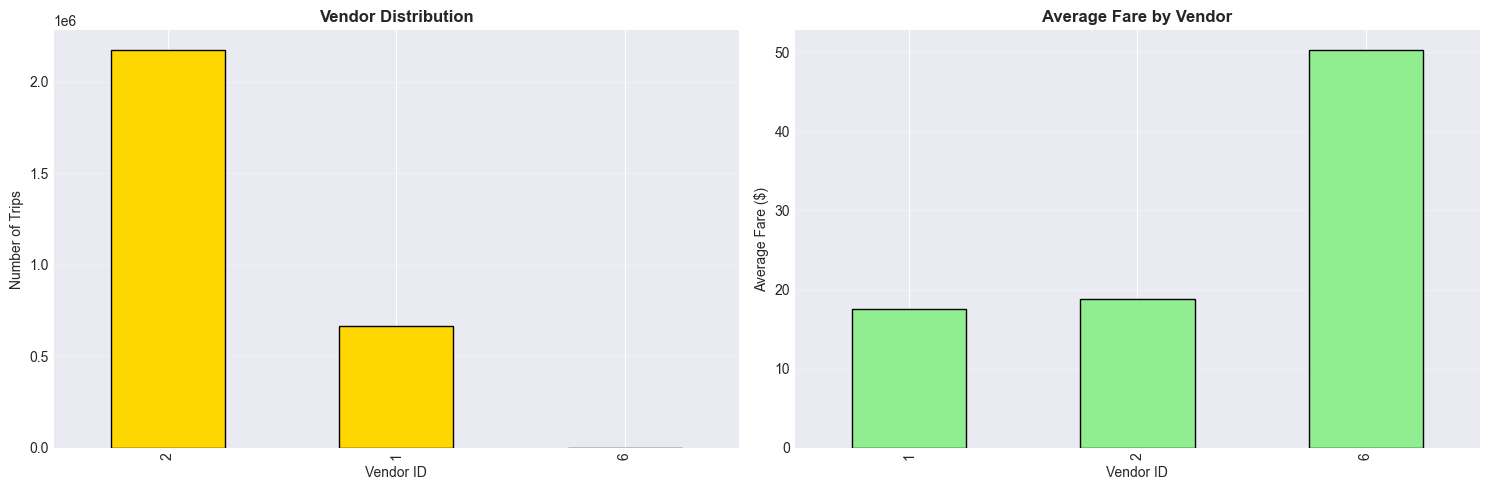

In [15]:
print('VENDOR ANALYSIS')
print('='*70)

vendor_dist = df['VendorID'].value_counts()
print(vendor_dist)

vendor_stats = df.groupby('VendorID').agg({
    'fare_amount': 'mean',
    'tip_amount': 'mean',
    'trip_distance': 'mean',
    'trip_duration_minutes': 'mean'
}).round(2)
print('\nVendor Statistics:')
print(vendor_stats)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

vendor_dist.plot(kind='bar', ax=axes[0], color='gold', edgecolor='black')
axes[0].set_title('Vendor Distribution', fontweight='bold')
axes[0].set_xlabel('Vendor ID')
axes[0].set_ylabel('Number of Trips')
axes[0].grid(True, alpha=0.3, axis='y')

vendor_stats['fare_amount'].plot(kind='bar', ax=axes[1], color='lightgreen', edgecolor='black')
axes[1].set_title('Average Fare by Vendor', fontweight='bold')
axes[1].set_xlabel('Vendor ID')
axes[1].set_ylabel('Average Fare ($)')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 7. Correlation Analysis

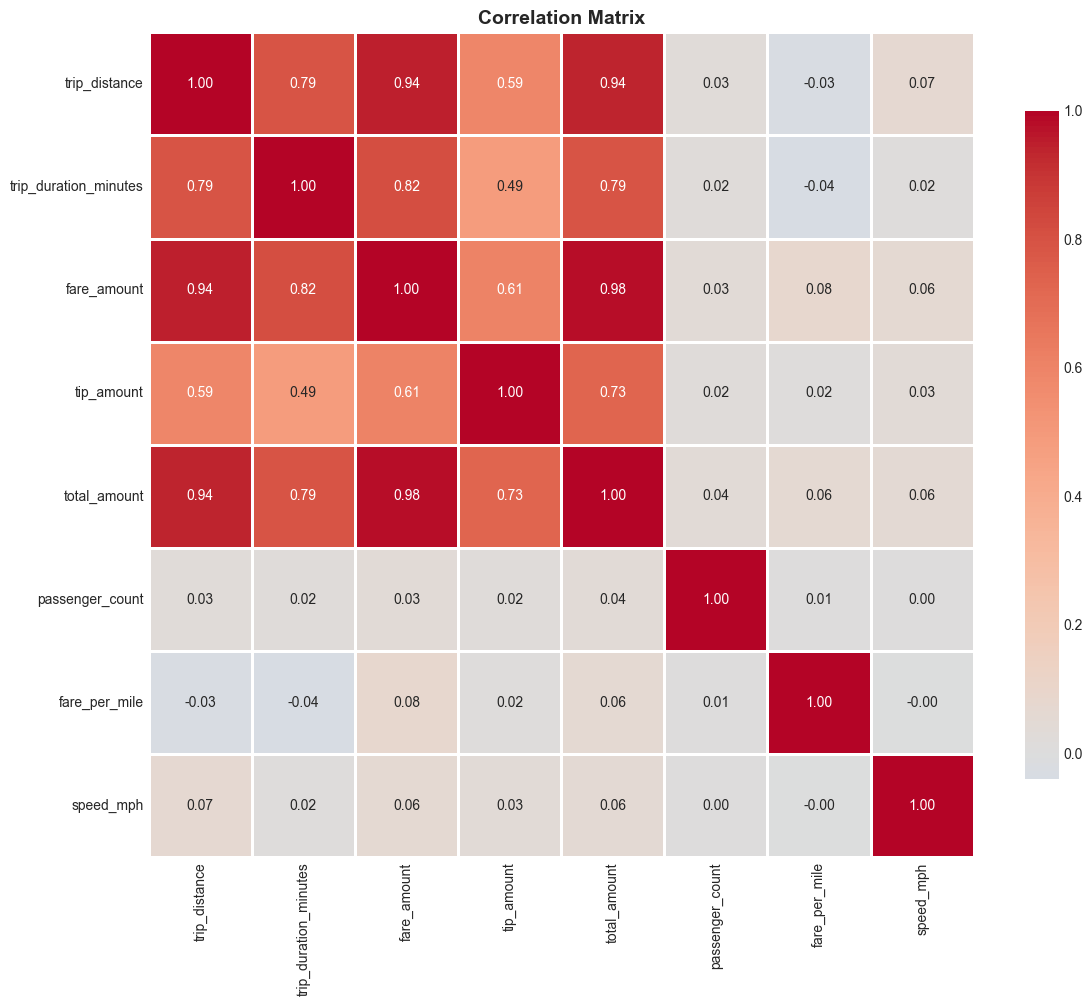


Strongest correlations with fare_amount:
fare_amount              1.000000
total_amount             0.978599
trip_distance            0.944711
trip_duration_minutes    0.815502
tip_amount               0.608674
fare_per_mile            0.079550
speed_mph                0.058521
passenger_count          0.034836
Name: fare_amount, dtype: float64


In [16]:
numerical_cols = ['trip_distance', 'trip_duration_minutes', 'fare_amount', 
                  'tip_amount', 'total_amount', 'passenger_count', 
                  'fare_per_mile', 'speed_mph']

corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8}, fmt='.2f')
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nStrongest correlations with fare_amount:')
print(corr_matrix['fare_amount'].sort_values(ascending=False))

## 8. Key Insights Summary

In [17]:
print('\nKEY INSIGHTS SUMMARY')
print('='*70)

print(f'\n1. DATASET:')
print(f'   Total trips: {len(df):,}')
print(f'   Date range: {df["pickup_date"].min()} to {df["pickup_date"].max()}')
print(f'   Avg trips/day: {df.groupby("pickup_date").size().mean():.0f}')

print(f'\n2. TEMPORAL:')
print(f'   Busiest hour: {df.groupby("pickup_hour").size().idxmax()}:00')
print(f'   Peak hour trips: {df["is_peak_hour"].sum():,} ({df["is_peak_hour"].sum()/len(df)*100:.1f}%)')
print(f'   Weekend trips: {df["is_weekend"].sum():,} ({df["is_weekend"].sum()/len(df)*100:.1f}%)')

print(f'\n3. FINANCIAL:')
print(f'   Avg fare: ${df["fare_amount"].mean():.2f}')
print(f'   Median fare: ${df["fare_amount"].median():.2f}')
print(f'   Trips with tips: {df["has_tip"].sum():,} ({df["has_tip"].sum()/len(df)*100:.1f}%)')
print(f'   Avg tip %: {df[df["has_tip"]==1]["tip_percentage"].mean():.1f}%')

print(f'\n4. TRIP CHARACTERISTICS:')
print(f'   Avg distance: {df["trip_distance"].mean():.2f} miles')
print(f'   Avg duration: {df["trip_duration_minutes"].mean():.1f} minutes')
print(f'   Avg speed: {df["speed_mph"].mean():.1f} mph')
print(f'   Avg passengers: {df["passenger_count"].mean():.2f}')

print(f'\n5. PAYMENT & VENDOR:')
print(f'   Credit card: {(df["payment_type"]==1).sum():,} ({(df["payment_type"]==1).sum()/len(df)*100:.1f}%)')
print(f'   Cash: {(df["payment_type"]==2).sum():,} ({(df["payment_type"]==2).sum()/len(df)*100:.1f}%)')
print(f'   Vendor 2: {(df["VendorID"]==2).sum():,} ({(df["VendorID"]==2).sum()/len(df)*100:.1f}%)')

print(f'\n{'='*70}')
print('Data preprocessing and EDA complete!')


KEY INSIGHTS SUMMARY

1. DATASET:
   Total trips: 2,837,246
   Date range: 2024-01-01 to 2024-01-31
   Avg trips/day: 91524

2. TEMPORAL:
   Busiest hour: 18:00
   Peak hour trips: 534,967 (18.9%)
   Weekend trips: 725,418 (25.6%)

3. FINANCIAL:
   Avg fare: $18.50
   Median fare: $12.80
   Trips with tips: 2,213,882 (78.0%)
   Avg tip %: 26.8%

4. TRIP CHARACTERISTICS:
   Avg distance: 3.30 miles
   Avg duration: 15.0 minutes
   Avg speed: 12.1 mph
   Avg passengers: 1.34

5. PAYMENT & VENDOR:
   Credit card: 2,272,120 (80.1%)
   Cash: 417,326 (14.7%)
   Vendor 2: 2,171,910 (76.5%)

Data preprocessing and EDA complete!


## 9. Save Cleaned Dataset

In [18]:
# Save cleaned data
output_file = 'yellow_tripdata_2024-01_cleaned.parquet'
df.to_parquet(output_file, index=False)
print(f'Cleaned dataset saved to: {output_file}')
print(f'Shape: {df.shape}')
print(f'Ready for hypothesis testing and statistical analysis!')

Cleaned dataset saved to: yellow_tripdata_2024-01_cleaned.parquet
Shape: (2837246, 32)
Ready for hypothesis testing and statistical analysis!
